In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
%matplotlib inline 

In [2]:
# 1 CRIM – Crime rate  -  Per capita crime rate  -  Higher crime → lower house price  -  
# Negative relationship

# 2 ZN – Residential zoning  -  % of land for large residential plots (>25,000 sq ft)  -  Higher ZN → rich areas → higher prices  - 
#  Positive relationship

# 3 INDUS – Industrial land  -  % of non-retail business land  -  More factories → pollution → cheaper houses  - 
#  Negative relationship

# 4 CHAS – Charles River dummy  -  1 = near river  -  0 = not near river  -  Houses near river are premium  -  
# Categorical (binary)

# 5 NOX – Pollution level  -  Nitric oxide concentration  -  More pollution → lower prices  -  
# Negative relationship

# 6 RM – Rooms  -  Average number of rooms per house  -  Bigger houses = expensive houses  -  
# Very strong positive

# 7 AGE – Old houses  -  % of houses built before 1940  -  Older houses → cheaper  -  
# Negative relationship

# 8 DIS – Distance from job centers  -  Weighted distance to Boston employment hubs  -  Farther = inconvenient → cheaper  -  
# Negative relationship

# 9 RAD – Highway access  -  Index of access to radial highways  -  Better connectivity → higher prices  -  
# Positive relationship

# 10 TAX – Property tax  -  Tax per $10,000 value  -  Higher tax → less demand  -  
# Negative relationship

# 11 PTRATIO – School quality  -  Pupil-teacher ratio  -  Lower ratio = better schools  -  Better schools → higher prices  -  
# Negative relationship

# 12 B – Demographic indicator  -  1000 * (Bk - 0.63)^2  -  Historical demographic proxy  -  
# Sensitive feature

# 13 LSTAT – Lower status population  -  % of lower income population  -  Higher LSTAT → cheaper homes  -  
# Strong negative


In [3]:
#load data 
housing = pd.read_csv('data.csv')
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,BIAS_COL
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,1
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1


In [4]:
housing = housing.drop('BIAS_COL',axis = 1)

In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       501 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
# Data exploration 

housing['CHAS'].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

In [7]:
housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.286277,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.704055,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.887000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.209000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


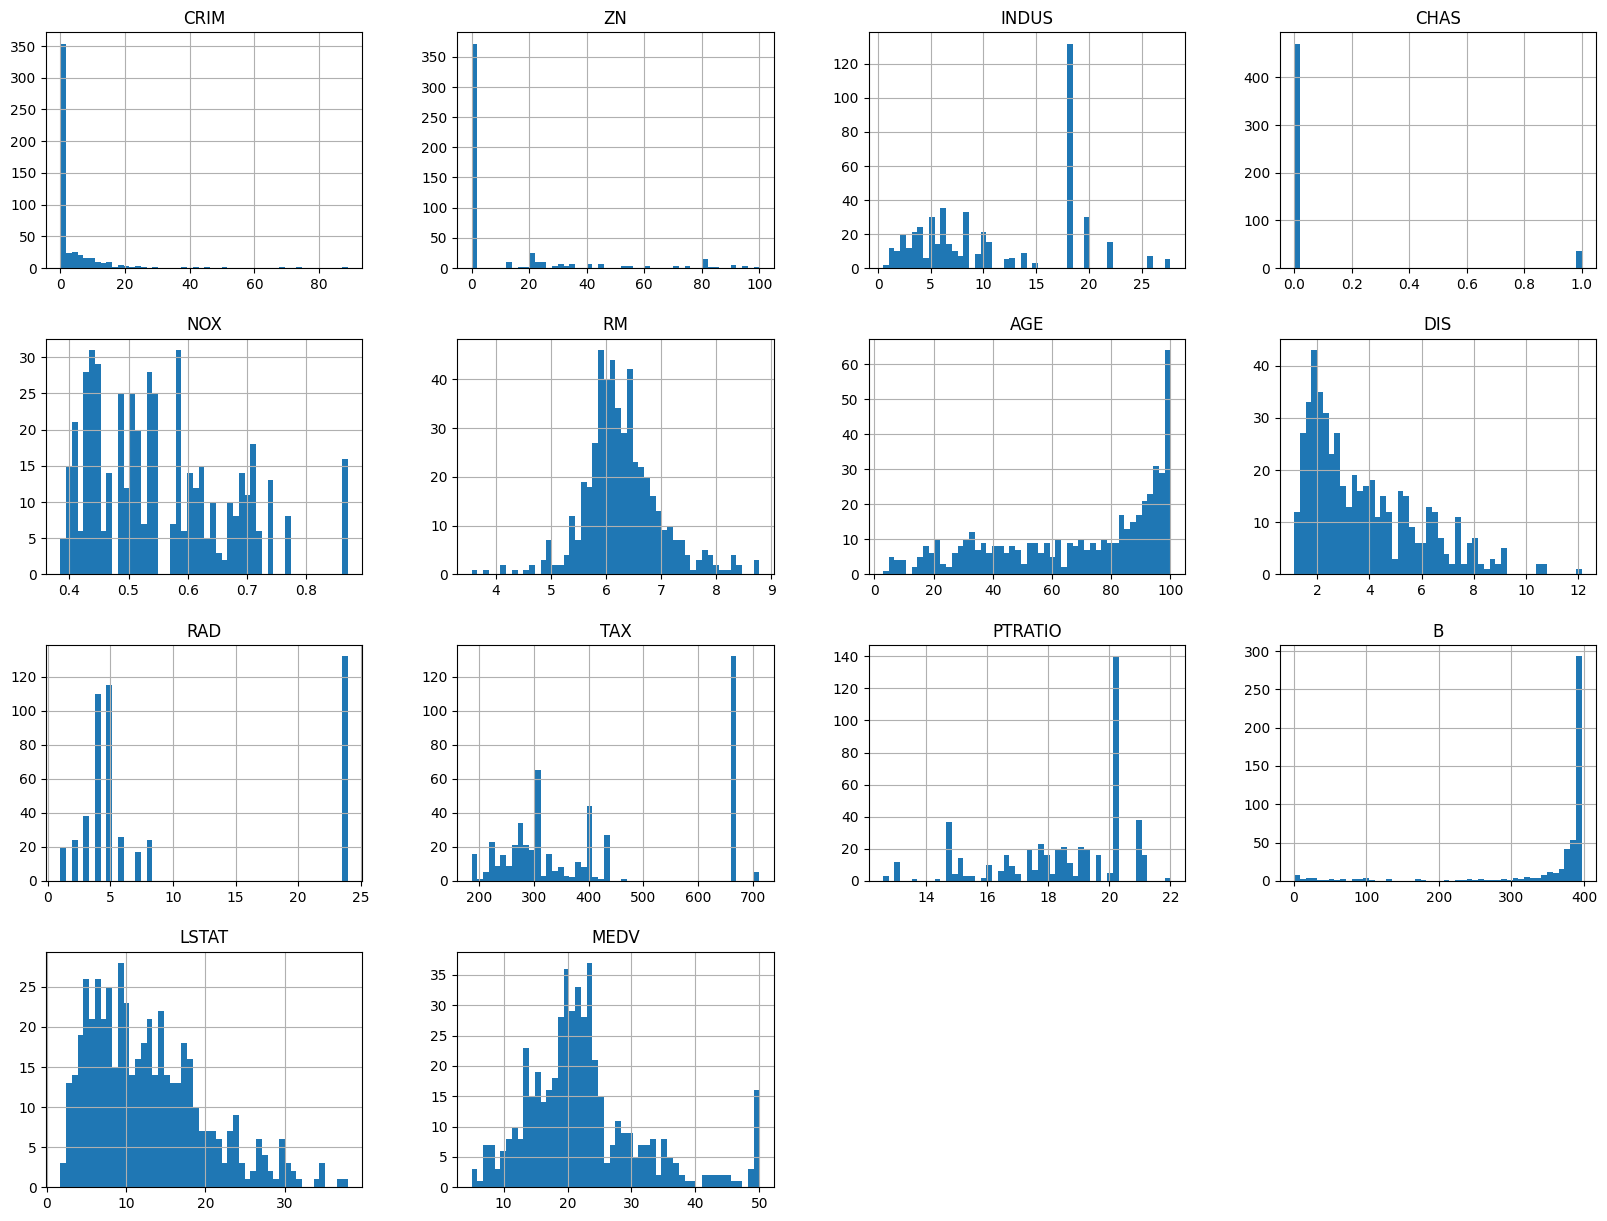

In [8]:
housing.hist(bins= 50 , figsize=(20,15))
plt.show()

## train test split 

In [9]:

'''
def split_train_test(data, test_ratio):
    np.random.seed(42)
    shuffled = np.random.permutation(len(data))                 # creates random indices  #[because ML models must not learn patterns from ordered data(randomness avoids bias)]
    test_set_size = int(len(data) * test_ratio)                 # decides test size 
    test_indices = shuffled[:test_set_size]                     # pick test size indeces   [first 101 random indices → test data]
    train_indices = shuffled[test_set_size:]                    # pick train size indeces [remaining indeces is train data ]
    return data.iloc[train_indices], data.iloc[test_indices]    #converts random indices into actual rows

train_set, test_set = split_train_test(housing, 0.2)            #80% data → training ; 20% data → testing [the main split assign]

print(f"Rows in train set: {len(train_set)}")
print(f"Rows in test set: {len(test_set)}")

'''


# this shows the working behind the sklearn code of train test split 



'\ndef split_train_test(data, test_ratio):\n    np.random.seed(42)\n    shuffled = np.random.permutation(len(data))                 # creates random indices  #[because ML models must not learn patterns from ordered data(randomness avoids bias)]\n    test_set_size = int(len(data) * test_ratio)                 # decides test size \n    test_indices = shuffled[:test_set_size]                     # pick test size indeces   [first 101 random indices → test data]\n    train_indices = shuffled[test_set_size:]                    # pick train size indeces [remaining indeces is train data ]\n    return data.iloc[train_indices], data.iloc[test_indices]    #converts random indices into actual rows\n\ntrain_set, test_set = split_train_test(housing, 0.2)            #80% data → training ; 20% data → testing [the main split assign]\n\nprint(f"Rows in train set: {len(train_set)}")\nprint(f"Rows in test set: {len(test_set)}")\n\n'

In [10]:

'''
# We want to split the data into train and test
# BUT in a way that important proportions (CHAS) stay the same
# This is called stratified sampling

from sklearn.model_selection import StratifiedShuffleSplit
# Importing StratifiedShuffleSplit:
# a tool that splits data randomly
# while preserving the distribution of a chosen column

splitcase = StratifiedShuffleSplit(
    n_splits=1,        # Number of splits to generate
                         # 1 means: create only ONE train-test split

    test_size=0.2,     # 20% of the data will go into the test set
                         # remaining 80% will be used for training

    random_state=42    # Fixes randomness so we get the SAME split every time
                         # Helps with reproducibility and debugging
)

# splitcase.split(...) does NOT return data
# it returns ROW INDICES for train and test sets
for train_index, test_index in splitcase.split(
        housing,            # Full dataset (rows will be split)
        housing['CHAS']     # Stratification column
                             # Ensures same proportion of CHAS=0 and CHAS=1
                             # in both train and test sets
):
    
    # Using the row indices to fetch actual rows for training
    strain_set = housing.loc[train_index]
    # .loc maps the row indices back to the original dataframe
    # Result: stratified training dataset (features + target together)

    # Using the row indices to fetch actual rows for testing
    stest_set = housing.loc[test_index]
    # Result: stratified test dataset (features + target together)
'''

"\n# We want to split the data into train and test\n# BUT in a way that important proportions (CHAS) stay the same\n# This is called stratified sampling\n\nfrom sklearn.model_selection import StratifiedShuffleSplit\n# Importing StratifiedShuffleSplit:\n# a tool that splits data randomly\n# while preserving the distribution of a chosen column\n\nsplitcase = StratifiedShuffleSplit(\n    n_splits=1,        # Number of splits to generate\n                         # 1 means: create only ONE train-test split\n\n    test_size=0.2,     # 20% of the data will go into the test set\n                         # remaining 80% will be used for training\n\n    random_state=42    # Fixes randomness so we get the SAME split every time\n                         # Helps with reproducibility and debugging\n)\n\n# splitcase.split(...) does NOT return data\n# it returns ROW INDICES for train and test sets\nfor train_index, test_index in splitcase.split(\n        housing,            # Full dataset (rows will 

In [11]:
# splitting data but in such a way it propotioned yet random 
# stratified sampling 

from sklearn.model_selection import StratifiedShuffleSplit
splitcase = StratifiedShuffleSplit(
    n_splits = 1,    # no.of splits / cut 
    test_size = 0.2, #i.e 20% ideal case 
    random_state = 42
)
for train_index ,test_index in splitcase.split(housing,housing['CHAS']):
    strain_set = housing.loc[train_index]
    stest_set = housing.loc[test_index]

``` 
X_train, X_test, y_train, y_test = train_test_split
(
    X, y, test_size=0.2, random_state=42, stratify=y
)

```

could have done this as well 

In [12]:
print(strain_set['CHAS'].value_counts())
print(376/28)

print(stest_set['CHAS'].value_counts())
print(95/7)

# both have same ratio: data is divided perfect for both 

CHAS
0    376
1     28
Name: count, dtype: int64
13.428571428571429
CHAS
0    95
1     7
Name: count, dtype: int64
13.571428571428571


In [13]:
# split here before correlation this works on train only 
housing = strain_set.copy()

## looking for correlation 

In [14]:
corr_matrix = housing.corr()  # gives out correaltion values 
corr_matrix['MEDV'].sort_values(ascending = False )

MEDV       1.000000
RM         0.679261
B          0.361761
ZN         0.339741
DIS        0.240451
CHAS       0.205066
AGE       -0.364596
RAD       -0.374693
CRIM      -0.393715
NOX       -0.422873
TAX       -0.456657
INDUS     -0.473516
PTRATIO   -0.493534
LSTAT     -0.740494
Name: MEDV, dtype: float64

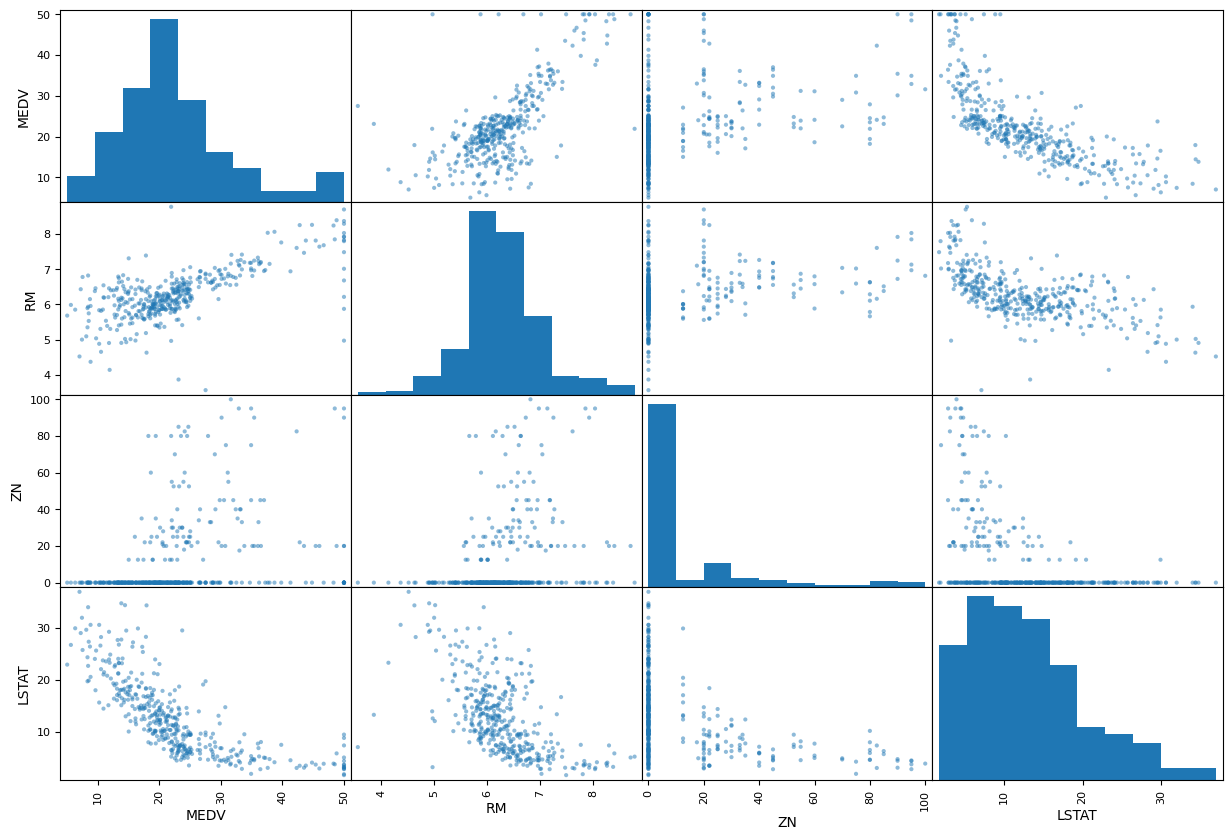

In [15]:
## understand by plotting 

from pandas.plotting import scatter_matrix
attr = ['MEDV','RM','ZN','LSTAT']
scatter_matrix(housing[attr],figsize=(15,10))
plt.show()

<Axes: xlabel='RM', ylabel='MEDV'>

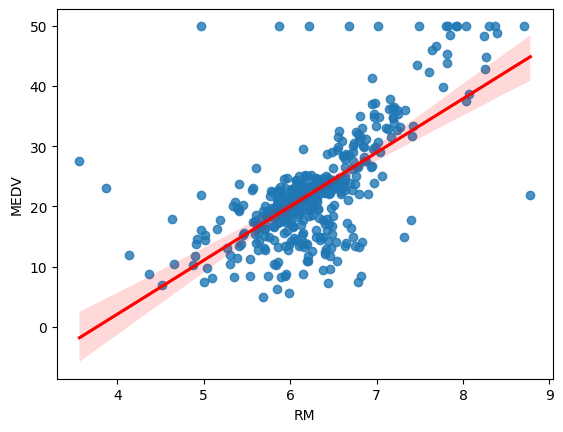

In [16]:
sns.regplot(x = 'RM',y="MEDV",data = housing,line_kws = {'color':'red'} )   
 # 50 has straignt line , RM is capped that means we dont have data beypnd that val

<Axes: xlabel='LSTAT', ylabel='MEDV'>

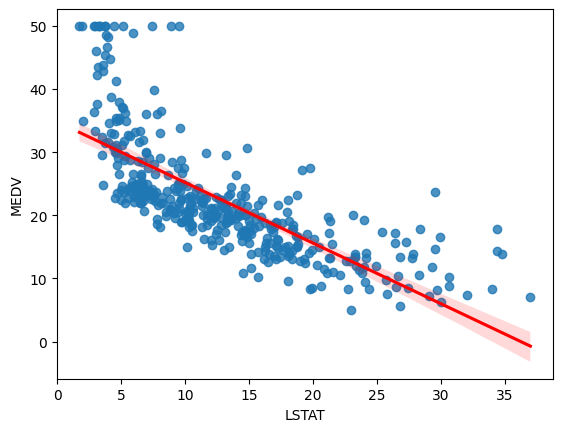

In [17]:
sns.regplot(x = 'LSTAT',y="MEDV",data = housing,line_kws = {'color':'red'} )

<Axes: xlabel='RM', ylabel='LSTAT'>

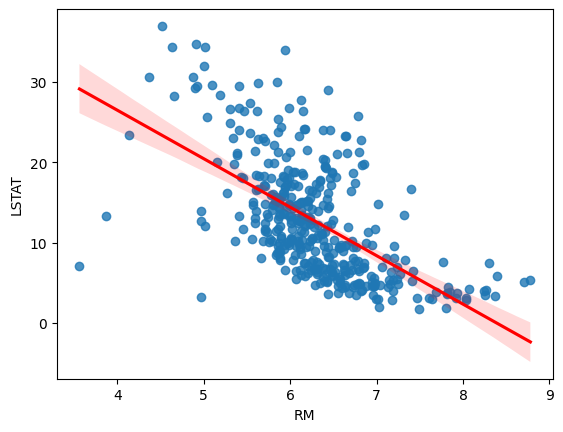

In [18]:
sns.regplot(x = 'RM',y="LSTAT",data = housing,line_kws = {'color':'red'} )

## ATTR combinations 

how do we know which combinations to keep?
* create combinations
* check correlation / MI
* train model
* use RFE / Lasso
* keep what improves performance


In [19]:
housing['TAXRM'] = housing['TAX']/housing['RM'] 
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAXRM
254,0.04819,80.0,3.64,0,0.392,6.108,32.0,9.2203,1,315,16.4,392.89,6.57,21.9,51.571709
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280,17.0,390.94,5.99,24.5,42.200452
476,4.87141,0.0,18.10,0,0.614,6.484,93.6,2.3053,24,666,20.2,396.21,18.68,16.7,102.714374
321,0.18159,0.0,7.38,0,0.493,6.376,54.3,4.5404,5,287,19.6,396.90,6.87,23.1,45.012547
326,0.30347,0.0,7.38,0,0.493,6.312,28.9,5.4159,5,287,19.6,396.90,6.15,23.0,45.468948


In [20]:
#sheck its correlation 
corr_matrix = housing.corr()  # gives out correaltion values 
corr_matrix['MEDV'].sort_values(ascending = False )

MEDV       1.000000
RM         0.679261
B          0.361761
ZN         0.339741
DIS        0.240451
CHAS       0.205066
AGE       -0.364596
RAD       -0.374693
CRIM      -0.393715
NOX       -0.422873
TAX       -0.456657
INDUS     -0.473516
PTRATIO   -0.493534
TAXRM     -0.530464
LSTAT     -0.740494
Name: MEDV, dtype: float64

<Axes: xlabel='TAXRM', ylabel='MEDV'>

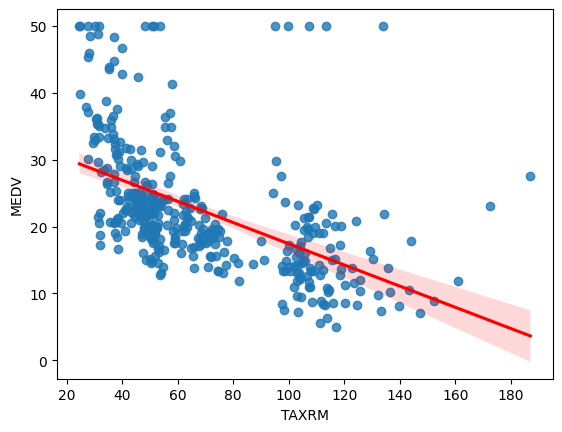

In [21]:
sns.regplot(x = 'TAXRM',y="MEDV",data = housing,line_kws = {'color':'red'})

# feature target seperation 

In [22]:
housing = strain_set.drop("MEDV", axis = 1)
htarget = strain_set['MEDV'].copy()

# handling missing data 

* deletion  of those points       
```housing.dropna(subset=['RM'])```
* get rid of whole attr          
 ```housing.dropna('RM',axis=1)```
* constant 0 , mean , median    
 ```housing['RM'].fillna(housing['RM'].meadian())``` 


In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
x = imputer.fit_transform(housing)
#this gives numpy array 

In [24]:
housing_tr = pd.DataFrame(x , columns = housing.columns)
housing_tr.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.04819,80.0,3.64,0.0,0.392,6.108,32.0,9.2203,1.0,315.0,16.4,392.89,6.57
1,0.01501,80.0,2.01,0.0,0.435,6.635,29.7,8.3440,4.0,280.0,17.0,390.94,5.99
2,4.87141,0.0,18.10,0.0,0.614,6.484,93.6,2.3053,24.0,666.0,20.2,396.21,18.68
3,0.18159,0.0,7.38,0.0,0.493,6.376,54.3,4.5404,5.0,287.0,19.6,396.90,6.87
4,0.30347,0.0,7.38,0.0,0.493,6.312,28.9,5.4159,5.0,287.0,19.6,396.90,6.15


# Scikit learn design 

Estimators – It estimates some parameter based on a dataset.
Eg. imputer.
It has a fit method and transform method.  [An estimator is any object that learns parameters from data using fit()]
Fit method – Fits the dataset and calculates internal parameters.

Transformers – transform method takes input and returns output based on the learnings from fit().
It also has a convenience function called fit_transform() which fits and then transforms.

Predictors – LinearRegression model is an example of predictor.
fit() and predict() are two common functions.
It also gives score() function which will evaluate the predictions.

```
imputer.fit(X_train)
X_train = imputer.transform(X_train)


scaler.fit(X_train)
X_train = scaler.transform(X_train)


model.fit(X_train, y_train)


```

# Creating Pipeline 

In [25]:
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 

my_pipeline = Pipeline([('imputer',SimpleImputer(strategy='median')),
                        ('std_scaler',StandardScaler()),
                        ])


# from everything it should be in pipeline 

In [26]:
housing_tr2 = my_pipeline.fit_transform(housing) # numpy array

In [27]:
housing_tr2.shape

(404, 13)

# Selecting Model 

## linear Regg

In [28]:
# from sklearn.linear_model import LinearRegression 
# model = LinearRegression()
# model.fit(housing_tr2 ,htarget)  #model fit(x,y)



## Decision Regressor 

In [29]:
# from sklearn.tree import DecisionTreeRegressor
# model = DecisionTreeRegressor()
# model.fit(housing_tr2 ,htarget)  #model.fit(x,y)

## Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(housing_tr2 ,htarget)  #model.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
some_data = housing.iloc[:5]

In [32]:
some_labels = htarget.iloc[:5]

In [33]:
prepared_data = my_pipeline.transform(some_data)

In [34]:
model.predict(prepared_data) #overfitting 

array([22.435, 25.673, 16.546, 23.429, 23.447])

In [35]:
list(some_labels)

[21.9, 24.5, 16.7, 23.1, 23.0]

### Evaluating model 

In [36]:
from sklearn.metrics import mean_squared_error
housing_predict = model.predict(housing_tr2)
mse = mean_squared_error(htarget , housing_predict )
rmse = np.sqrt(mse)

In [37]:
rmse   # model is onow overfitted as it learned everything byhearted 

np.float64(1.257615188708885)

Using better evaluation tech - Cross Validation 


In [38]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,housing_tr2,htarget,scoring = 'neg_mean_squared_error',cv = 10)   # sklearn assumes higher score = better : but MSE is lower = better
rmse_scores = np.sqrt(-scores)        # turn negative score back to positive 
rmse_scores 


array([2.78901673, 2.59952256, 4.31788334, 2.59720522, 3.66688582,
       2.79707234, 4.84284248, 3.28299561, 2.82506926, 3.17517688])

In [39]:
def print_scores(scores):
    print('scores:',scores)
    print('scores mean:',scores.mean())
    print('scores sd:',scores.std())

print_scores(rmse_scores)

scores: [2.78901673 2.59952256 4.31788334 2.59720522 3.66688582 2.79707234
 4.84284248 3.28299561 2.82506926 3.17517688]
scores mean: 3.28936702516335
scores sd: 0.7273226554772276


Linear Reggression :
* scores mean: 5.029717031448928
* scores sd: 1.0551493903530322

Decision Tree :
* scores mean: 4.376131962292186
* scores sd: 0.8273316053373679


Random Forest :
* scores mean: 3.346784211031727
* scores sd: 0.725117473852544




In [40]:
X_test = stest_set.drop('MEDV',axis = 1)
y_test = stest_set['MEDV'].copy()
X_test_prepared = my_pipeline.transform(X_test)
final_predictions = model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test,final_predictions)
final_rmse = np.sqrt(final_mse)
print(final_rmse)
print(final_predictions ,'\n', list(y_test))

2.999387177604196
[24.597 12.004 26.498 22.057 18.856 15.182 19.844 14.782 32.044 40.833
 19.799 12.055 24.204 26.939 19.447 11.336 32.674 14.327 23.777 18.288
 19.775 17.846 17.277 22.369 18.873 31.457 16.176 32.927  8.518 33.917
 23.333 21.369 23.084 11.018 21.271 11.223 43.83  24.709 23.403 42.923
 23.777 29.848 20.275 21.01  19.151 33.762 44.098 20.158 20.598 21.905
 21.721 14.592 21.514 15.224 25.15  32.979 40.989 29.153 19.457 21.103
 46.88  10.013 19.069 25.552 14.585 34.256 20.269 18.087 19.241 34.655
 26.377 22.846 21.095 22.462 35.118 12.418 15.801 20.096 20.69  21.493
 22.697 21.438 13.9   22.714 20.767 21.045 13.688 21.869 21.992 22.983
 18.106 27.005  7.464 26.471 19.419 29.168 20.059 34.356 14.582 26.837
 21.636 19.899] 
 [16.5, 10.2, 30.1, 23.0, 14.4, 15.6, 19.4, 14.1, 30.3, 35.2, 23.1, 13.8, 25.0, 27.9, 19.5, 12.3, 32.2, 13.5, 23.8, 21.7, 19.2, 19.5, 10.4, 23.2, 18.6, 28.5, 15.2, 32.0, 7.2, 34.6, 20.1, 20.6, 23.6, 13.1, 23.8, 12.7, 43.1, 24.7, 22.2, 44.0, 28.1, 31.0, 21

In [41]:
prepared_data[0]

array([-0.43942006,  3.12628155, -1.12165014, -0.27288841, -1.42262747,
       -0.24393046, -1.31238772,  2.61111401, -1.0016859 , -0.5778192 ,
       -0.97491834,  0.41164221, -0.86091034])

In [42]:
import joblib

joblib.dump(model, "model.pkl")


['model.pkl']

In [43]:
joblib.dump(my_pipeline, "pipeline.pkl")


['pipeline.pkl']